In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
df=pd.read_csv('/content/disasterIND.csv')
df.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,1900-9001-IND,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,2.730451,NaN,01-12-2006,25-09-2023
1,1905-0003-IND,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,IND,...,NaN,NaN,NaN,NaN,25000.0,847777.0,2.948887,NaN,01-07-2003,25-09-2023
2,1907-0001-IND,Yes,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Bubonic,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,3.058105,NaN,01-07-2003,25-09-2023
3,1916-0004-IND,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,3.576717,NaN,01-07-2003,25-09-2023
4,1920-0001-IND,Yes,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Bubonic,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,6.562784,NaN,01-07-2003,25-09-2023


In [ ]:
df=df.drop(columns=['Entry Date','Last Update',"Reconstruction Costs ('000 US$)","Reconstruction Costs, Adjusted ('000 US$)",'External IDs','DisNo.','Classification Key','ISO','Country','Subregion','Region','CPI','Appeal','Declaration','OFDA/BHA Response',"AID Contribution ('000 US$)",'Historic',"Insured Damage ('000 US$)","Insured Damage, Adjusted ('000 US$)","Total Damage ('000 US$)","Total Damage, Adjusted ('000 US$)",'Disaster Group','Event Name'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  783 non-null    object 
 1   Disaster Type      783 non-null    object 
 2   Disaster Subtype   783 non-null    object 
 3   Location           733 non-null    object 
 4   Origin             219 non-null    object 
 5   Associated Types   136 non-null    object 
 6   Magnitude          217 non-null    float64
 7   Magnitude Scale    695 non-null    object 
 8   Latitude           93 non-null     float64
 9   Longitude          93 non-null     float64
 10  River Basin        84 non-null     object 
 11  Start Year         783 non-null    int64  
 12  Start Month        768 non-null    float64
 13  Start Day          588 non-null    float64
 14  End Year           783 non-null    int64  
 15  End Month          763 non-null    float64
 16  End Day            589 non

In [ ]:
df = df.dropna(subset=['Location'])

In [ ]:
df['Location'] = df['Location'].str.strip().str.lower()

In [ ]:
df.head()

,Disaster Subgroup,Disaster Type,Disaster Subtype,Location,Origin,Associated Types,Magnitude,Magnitude Scale,Latitude,Longitude,...,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Admin Units
0,Climatological,Drought,Drought,bengal,NaN,NaN,NaN,Km2,NaN,NaN,...,NaN,1900,NaN,NaN,1250000.0,NaN,NaN,NaN,NaN,NaN
1,Geophysical,Earthquake,Ground movement,kangra,NaN,NaN,7.8,Moment Magnitude,32.04,76.16,...,4.0,1905,4.0,4.0,20000.0,NaN,NaN,NaN,NaN,NaN
3,Meteorological,Storm,Tropical cyclone,"cuddalore, pondicherry",NaN,NaN,NaN,Kph,NaN,NaN,...,21.0,1916,11.0,21.0,300.0,NaN,NaN,NaN,NaN,NaN
7,Meteorological,Storm,Tropical cyclone,punjab province,NaN,NaN,NaN,Kph,NaN,NaN,...,23.0,1924,9.0,23.0,1242.0,NaN,1000000.0,NaN,1000000.0,NaN
8,Meteorological,Storm,Tropical cyclone,"bezwada, masulipatam",NaN,NaN,NaN,Kph,NaN,NaN,...,10.0,1925,5.0,10.0,80.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['Location'] = df['Location'].str.split(',').str[0]

In [ ]:
df.head()

,Disaster Subgroup,Disaster Type,Disaster Subtype,Location,Origin,Associated Types,Magnitude,Magnitude Scale,Latitude,Longitude,...,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Admin Units
0,Climatological,Drought,Drought,bengal,NaN,NaN,NaN,Km2,NaN,NaN,...,NaN,1900,NaN,NaN,1250000.0,NaN,NaN,NaN,NaN,NaN
1,Geophysical,Earthquake,Ground movement,kangra,NaN,NaN,7.8,Moment Magnitude,32.04,76.16,...,4.0,1905,4.0,4.0,20000.0,NaN,NaN,NaN,NaN,NaN
3,Meteorological,Storm,Tropical cyclone,cuddalore,NaN,NaN,NaN,Kph,NaN,NaN,...,21.0,1916,11.0,21.0,300.0,NaN,NaN,NaN,NaN,NaN
7,Meteorological,Storm,Tropical cyclone,punjab province,NaN,NaN,NaN,Kph,NaN,NaN,...,23.0,1924,9.0,23.0,1242.0,NaN,1000000.0,NaN,1000000.0,NaN
8,Meteorological,Storm,Tropical cyclone,bezwada,NaN,NaN,NaN,Kph,NaN,NaN,...,10.0,1925,5.0,10.0,80.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 733 entries, 0 to 782
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  733 non-null    object 
 1   Disaster Type      733 non-null    object 
 2   Disaster Subtype   733 non-null    object 
 3   Location           733 non-null    object 
 4   Origin             219 non-null    object 
 5   Associated Types   136 non-null    object 
 6   Magnitude          217 non-null    float64
 7   Magnitude Scale    654 non-null    object 
 8   Latitude           93 non-null     float64
 9   Longitude          93 non-null     float64
 10  River Basin        84 non-null     object 
 11  Start Year         733 non-null    int64  
 12  Start Month        728 non-null    float64
 13  Start Day          581 non-null    float64
 14  End Year           733 non-null    int64  
 15  End Month          723 non-null    float64
 16  End Day            582 non-null

In [ ]:
city_dataset = pd.read_csv('/content/India Cities LatLng.csv')

In [ ]:
city_dataset.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Delhi,28.6600,77.2300,India,IN,Delhi,admin,29617000.0,16753235.0
1,Mumbai,18.9667,72.8333,India,IN,Mahārāshtra,admin,23355000.0,12478447.0
2,Kolkāta,22.5411,88.3378,India,IN,West Bengal,admin,17560000.0,4496694.0
3,Bangalore,12.9699,77.5980,India,IN,Karnātaka,admin,13707000.0,8443675.0
4,Chennai,13.0825,80.2750,India,IN,Tamil Nādu,admin,11324000.0,6727000.0


In [ ]:
city_dataset['city'] = city_dataset['city'].str.lower().str.strip()

In [ ]:
state_coords = {
    'new delhi':(28.6139, 77.2090),
    'jammu and kashmir':(33.7782, 76.5762),
    'andhra pradesh': (15.9129, 79.7400),
    'arunachal pradesh': (28.2180, 94.7278),
    'assam': (26.2006, 92.9376),
    'bihar': (25.0961, 85.3131),
    'chhattisgarh': (21.2787, 81.8661),
    'goa': (15.2993, 74.1240),
    'gujarat': (22.2587, 71.1924),
    'haryana': (29.0588, 76.0856),
    'himachal pradesh': (31.1048, 77.1734),
    'jharkhand': (23.6102, 85.2799),
    'karnataka': (15.3173, 75.7139),
    'kerala': (10.8505, 76.2711),
    'madhya pradesh': (22.9734, 78.6569),
    'maharashtra': (19.7515, 75.7139),
    'manipur': (24.6637, 93.9063),
    'meghalaya': (25.4670, 91.3662),
    'mizoram': (23.1645, 92.9376),
    'nagaland': (26.1584, 94.5624),
    'odisha': (20.9517, 85.0985),
    'punjab': (31.1471, 75.3412),
    'rajasthan': (27.0238, 74.2179),
    'sikkim': (27.5330, 88.5122),
    'tamil nadu': (11.1271, 78.6569),
    'telangana': (18.1124, 79.0193),
    'tripura': (23.9408, 91.9882),
    'uttar pradesh': (26.8467, 80.9462),
    'uttarakhand': (30.0668, 79.0193),
    'west bengal': (22.9868, 87.8550)
}

In [ ]:
import unicodedata

def clean_text(text):
    if isinstance(text, str):
        text = unicodedata.normalize('NFKD', text)
        text = text.encode('ascii', 'ignore').decode('utf-8')
        return text.lower().strip()
    return text

In [ ]:
city_dataset['city'] = city_dataset['city'].apply(clean_text)

In [ ]:
city_dataset.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,delhi,28.6600,77.2300,India,IN,Delhi,admin,29617000.0,16753235.0
1,mumbai,18.9667,72.8333,India,IN,Mahārāshtra,admin,23355000.0,12478447.0
2,kolkata,22.5411,88.3378,India,IN,West Bengal,admin,17560000.0,4496694.0
3,bangalore,12.9699,77.5980,India,IN,Karnātaka,admin,13707000.0,8443675.0
4,chennai,13.0825,80.2750,India,IN,Tamil Nādu,admin,11324000.0,6727000.0


In [ ]:
df['Latitude'] = df['Latitude'].combine_first(
    df['Location'].map(lambda x: state_coords.get(x, (None, None))[0])
)

df['Longitude'] = df['Longitude'].combine_first(
    df['Location'].map(lambda x: state_coords.get(x, (None, None))[1])
)

In [ ]:
df.head(50)

,Disaster Subgroup,Disaster Type,Disaster Subtype,Location,Origin,Associated Types,Magnitude,Magnitude Scale,Latitude,Longitude,...,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Admin Units
0,Climatological,Drought,Drought,bengal,NaN,NaN,NaN,Km2,NaN,NaN,...,NaN,1900,NaN,NaN,1250000.0,NaN,NaN,NaN,NaN,NaN
1,Geophysical,Earthquake,Ground movement,kangra,NaN,NaN,7.8,Moment Magnitude,32.0400,76.1600,...,4.0,1905,4.0,4.0,20000.0,NaN,NaN,NaN,NaN,NaN
3,Meteorological,Storm,Tropical cyclone,cuddalore,NaN,NaN,NaN,Kph,NaN,NaN,...,21.0,1916,11.0,21.0,300.0,NaN,NaN,NaN,NaN,NaN
7,Meteorological,Storm,Tropical cyclone,punjab province,NaN,NaN,NaN,Kph,NaN,NaN,...,23.0,1924,9.0,23.0,1242.0,NaN,1000000.0,NaN,1000000.0,NaN
8,Meteorological,Storm,Tropical cyclone,bezwada,NaN,NaN,NaN,Kph,NaN,NaN,...,10.0,1925,5.0,10.0,80.0,NaN,NaN,NaN,NaN,NaN
10,Hydrological,Flood,Riverine flood,bengal,NaN,NaN,NaN,Km2,NaN,NaN,...,19.0,1926,7.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN
11,Meteorological,Storm,Tropical cyclone,gujarat,NaN,NaN,NaN,Kph,22.2587,71.1924,...,23.0,1927,7.0,23.0,56.0,10.0,40000.0,NaN,40010.0,NaN
12,Meteorological,Storm,Tropical cyclone,nellore,NaN,NaN,NaN,Kph,NaN,NaN,...,1.0,1927,11.0,1.0,629.0,NaN,NaN,NaN,NaN,NaN
13,Hydrological,Flood,Flood (General),godavari,NaN,NaN,NaN,Km2,NaN,NaN,...,19.0,1928,10.0,19.0,36.0,NaN,NaN,2000.0,2000.0,NaN
14,Meteorological,Storm,Storm (General),madras,NaN,NaN,NaN,Kph,NaN,NaN,...,13.0,1935,11.0,13.0,100.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
city_dataset.rename(columns={'city': 'Location'}, inplace=True)

In [ ]:
city_dataset.rename(columns={
    'lat': 'Latitude',
    'lng': 'Longitude'
}, inplace=True)

In [ ]:
df = df.merge(city_dataset, on='Location', how='left', suffixes=('', '_city'))

In [ ]:
df=df.drop(columns=['iso2','admin_name','capital','population','population_proper'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  733 non-null    object 
 1   Disaster Type      733 non-null    object 
 2   Disaster Subtype   733 non-null    object 
 3   Location           733 non-null    object 
 4   Origin             219 non-null    object 
 5   Associated Types   136 non-null    object 
 6   Magnitude          217 non-null    float64
 7   Magnitude Scale    654 non-null    object 
 8   Latitude           325 non-null    float64
 9   Longitude          325 non-null    float64
 10  River Basin        84 non-null     object 
 11  Start Year         733 non-null    int64  
 12  Start Month        728 non-null    float64
 13  Start Day          581 non-null    float64
 14  End Year           733 non-null    int64  
 15  End Month          723 non-null    float64
 16  End Day            582 non

In [ ]:
df['Latitude'] = df['Latitude'].combine_first(df['Latitude_city'])
df['Longitude'] = df['Longitude'].combine_first(df['Longitude_city'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  733 non-null    object 
 1   Disaster Type      733 non-null    object 
 2   Disaster Subtype   733 non-null    object 
 3   Location           733 non-null    object 
 4   Origin             219 non-null    object 
 5   Associated Types   136 non-null    object 
 6   Magnitude          217 non-null    float64
 7   Magnitude Scale    654 non-null    object 
 8   Latitude           367 non-null    float64
 9   Longitude          367 non-null    float64
 10  River Basin        84 non-null     object 
 11  Start Year         733 non-null    int64  
 12  Start Month        728 non-null    float64
 13  Start Day          581 non-null    float64
 14  End Year           733 non-null    int64  
 15  End Month          723 non-null    float64
 16  End Day            582 non

In [ ]:
df.head(10)

,Disaster Subgroup,Disaster Type,Disaster Subtype,Location,Origin,Associated Types,Magnitude,Magnitude Scale,Latitude,Longitude,...,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Admin Units,Latitude_city,Longitude_city,country
0,Climatological,Drought,Drought,bengal,NaN,NaN,NaN,Km2,NaN,NaN,...,NaN,1250000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geophysical,Earthquake,Ground movement,kangra,NaN,NaN,7.8,Moment Magnitude,32.0400,76.1600,...,4.0,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meteorological,Storm,Tropical cyclone,cuddalore,NaN,NaN,NaN,Kph,NaN,NaN,...,21.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Meteorological,Storm,Tropical cyclone,punjab province,NaN,NaN,NaN,Kph,NaN,NaN,...,23.0,1242.0,NaN,1000000.0,NaN,1000000.0,NaN,NaN,NaN,NaN
4,Meteorological,Storm,Tropical cyclone,bezwada,NaN,NaN,NaN,Kph,16.5167,80.6167,...,10.0,80.0,NaN,NaN,NaN,NaN,NaN,16.5167,80.6167,India
5,Hydrological,Flood,Riverine flood,bengal,NaN,NaN,NaN,Km2,NaN,NaN,...,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Meteorological,Storm,Tropical cyclone,gujarat,NaN,NaN,NaN,Kph,22.2587,71.1924,...,23.0,56.0,10.0,40000.0,NaN,40010.0,NaN,NaN,NaN,NaN
7,Meteorological,Storm,Tropical cyclone,nellore,NaN,NaN,NaN,Kph,14.4333,79.9667,...,1.0,629.0,NaN,NaN,NaN,NaN,NaN,14.4333,79.9667,India
8,Hydrological,Flood,Flood (General),godavari,NaN,NaN,NaN,Km2,NaN,NaN,...,19.0,36.0,NaN,NaN,2000.0,2000.0,NaN,NaN,NaN,NaN
9,Meteorological,Storm,Storm (General),madras,NaN,NaN,NaN,Kph,NaN,NaN,...,13.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.drop(['Latitude_city', 'Longitude_city'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  733 non-null    object 
 1   Disaster Type      733 non-null    object 
 2   Disaster Subtype   733 non-null    object 
 3   Location           733 non-null    object 
 4   Origin             219 non-null    object 
 5   Associated Types   136 non-null    object 
 6   Magnitude          217 non-null    float64
 7   Magnitude Scale    654 non-null    object 
 8   Latitude           367 non-null    float64
 9   Longitude          367 non-null    float64
 10  River Basin        84 non-null     object 
 11  Start Year         733 non-null    int64  
 12  Start Month        728 non-null    float64
 13  Start Day          581 non-null    float64
 14  End Year           733 non-null    int64  
 15  End Month          723 non-null    float64
 16  End Day            582 non

In [ ]:
missing = df[df['Latitude'].isnull()]
print("Missing locations:\n", missing['Location'].unique())

Missing locations:
 ['bengal' 'cuddalore' 'punjab province' 'godavari' 'madras'
 'guntur (madras)' 'orissa' 'calcutta' 'rajputana'
 'east & west godavari districts' 'saurashtra' 'west' 'parganas'
 'madya pradesh' 'vishakhapatam' 'madras city' 'kutch' 'maduri' 'north'
 'central' 'rameswaram' 'nationwide except south' 'madras state'
 '(1) rajasthan' 'ramanathapurum' 'kannaman' 'north-east'
 'madras city (tamil nadu)' 'east coast' 'brahmaputra' 'midnapore'
 'tinsukia' 'northwest' 'eastern' 'bulandshar (uttar pradesh)'
 'madras/nellore (andhra pradesh)' 'krishna district'
 'between nellore and kavali (andhra pradesh)' 'ganges region'
 'north of nellore district' 'northeastern' 'lahaul' 'north west'
 'northern' 'srikakulam' 'puri' 'northeast' 'orissa state'
 'north-east region' 'districts of bhiwani'
 'saurashtra coast (n-w. gujarat)' 'upper assama' 'central - western'
 'north-east states' 'jammu region' 'tamil nadu state + chittoor'
 'ravalaseema' 'w bengal state' 'ladakh area' 'w bengal' 

In [ ]:
missing_count = df[['Latitude', 'Longitude']].isnull().any(axis=1).sum()

print("Number of rows with missing lat/long:", missing_count)

Number of rows with missing lat/long: 366


In [ ]:
Missinglocations= ['bengal' 'cuddalore' 'punjab province' 'godavari' 'madras'
 'guntur (madras)' 'orissa' 'calcutta' 'rajputana'
 'east & west godavari districts' 'saurashtra' 'west' 'parganas'
 'madya pradesh' 'vishakhapatam' 'madras city' 'kutch' 'maduri' 'north'
 'central' 'rameswaram' 'nationwide except south' 'madras state'
 '(1) rajasthan' 'ramanathapurum' 'kannaman' 'north-east'
 'madras city (tamil nadu)' 'east coast' 'brahmaputra' 'midnapore'
 'tinsukia' 'northwest' 'eastern' 'bulandshar (uttar pradesh)'
 'madras/nellore (andhra pradesh)' 'krishna district'
 'between nellore and kavali (andhra pradesh)' 'ganges region'
 'north of nellore district' 'northeastern' 'lahaul' 'north west'
 'northern' 'srikakulam' 'puri' 'northeast' 'orissa state'
 'north-east region' 'districts of bhiwani'
 'saurashtra coast (n-w. gujarat)' 'upper assama' 'central - western'
 'north-east states' 'jammu region' 'tamil nadu state + chittoor'
 'ravalaseema' 'w bengal state' 'ladakh area' 'w bengal' 'western'
 'punjab (western)' 'eastern uttar pradesh' 'rajasthan state'
 'south bihar' 'jammu and kashmir state' 'cashmire' 'cachemire' 'kashmir'
 'jammu and kashmir' 'gujarat state' 'along nepal/uttar pradesh border'
 'coastal orissa' 'southern india' 'north india' 'golfe du bengale'
 'tami nadu state' 'ganjam district (orissa)' 'bombay (assam state)'
 'bombay' 'near thondebhavi (karnataka)' 'kerala state' 'nagaon'
 'west bengal state' 'naogoan district (assam state)' 'vamanapuram'
 'aizawl (mizoram state)' 'bihar state' 'near kandi (murshidabad district'
 'karnataka state' 'surat (gujarat state)' 'mormugao' 'kashmir province'
 'mizoram state' 'kulla (himachal pradesh)' 'sikkim state' 'oman sea'
 'jammu & kashmir state' 'east and west godavari' 'kishanganj'
 'gangtok (city) level 1 = sikkim'
 'darjeeling hills level 1 = west bengal'
 'coastal districts of west bengal (no better info)' 'mehsana'
 'guntoor (guntur) and prakasham districts (andhra pradesh)' 'valsad'
 'lucknow (city) level 1 = uttar pradesh' 'kahool' 'tanton'
 'malpa village (pithoragrah district'
 'mansuna village (uttar pradesh state)'
 'bombay (city) level 1 = maharashtra' 'level 1 = uttar pradesh'
 'west begala' 'garhwal & kumaon (districts of nainital' 'gujarat coast'
 'kendrapara' 'khanpur' 'masarkal' 'tehri garhwal disrict' 'gonda'
 'andhra pradesh province' 'yingkiang'
 'ghatkopar village (mumbai suburban district' 'east siang' 'katihar'
 'pithoragarh' 'adilabad' 'birbhum' 'andhra pradesh state'
 'north 24 parganas district (west bengal province)' 'nagappattinam'
 'supaul district (bihar)' 'nawadah district (bihar)'
 'new delhi city (delhi province)' 'siliguri (west bengal)'
 'silchar city (cachar district' 'marshagal' 'uttar pradesh province'
 'hosdurg borough (kanhangad city' 'idukki'
 'rudra prayag district (uttarakhand province)'
 'chamba district (himachal pradesh province)' 'delhi province'
 'gopalganj' 'saran' 'amboori village (thiruvananthapuram district'
 'mandi district' 'west bengal province' 'orissa province'
 'gobalpur area (hugli district' 'barpeta'
 'tehri garhwal district (uttaranchal province)'
 'balaghat district (madhya pradesh province)'
 'bharuch district (gujarat province)' 'kannur' 'baleshwar'
 'saharanpur (uttar pradesh)' 'betul district (madhya pradesh province)'
 'jammu and kashmir (40424 to 40431)' 'gujarat province' 'bankura'
 'administrative unit not available district (jammu and kashmir province)'
 'chirakhawa' 'mekhliganj' 'khavda' 'krishna'
 'kullu district (himachal pradesh province)'
 'solang village (kullu district' 'leimapokpam' 'darbhanga' 'wayanad'
 'goalpara district (assam province)'
 'administrative unit not available districts (jammu and kashmir province)'
 'kolkata district (west bengal province)'
 'mokokchung district (nagaland province)' 'digras' 'sangla'
 'yingkiong village (upper siang (70051) district' 'ashoknagar'
 'guwahati city (kamrup district'
 'azamgarh district (uttar pradesh province)' 'maharashtra state'
 'raj nandgaon' 'east midnapore' 'uttar pradesh and bihar states'
 'tamil nadu province' 'andhra prasdesh' 'barmer'
 'madhya pradesh province' 'jammu and kashmir province' 'thiruvallur'
 'kendrapara district (orissa province)' 'sagar'
 'pithoragarh district (uttarakhand province)' 'lal'
 'jainta hills district (meghalaya province)'
 "srinagar city ('72808' district" 'bongaigaon'
 'nawabganj town (gonda district' 'mushalpur'
 'cuddalore district (tamil nadu province)' 'karnataka province'
 'adminitrative unit not available districts (jammu and kashmir province)'
 'himachel pradesh province' 'sultanpur' 'doda'
 'ghaziabad district (utar pradesh province)' 'assam province'
 'malin village (pune district' 'jammu and kashmir provinces'
 'tura village (west garo hills district' 'vishakhapatnam' 'shravasti'
 'odisha province' 'muzaffarnagar district (uttar pradesh province)'
 'hyderabad district (andhra pradesh province)' 'tripura province'
 'purnia' 'mirik' 'dhemaji' 'sonitpur' 'deogarh' 'maharashtra province'
 'jammu and kashmir (administrative unit not available) (siachen glacier)'
 'uttarakhand province (including almora' 'uttarakhand province'
 'lakhimpur' 'biha' 'maharashtra (nashik'
 'chennai district (tamil nadu province); andhra pradesh' 'jorhat'
 'sonamanrg (ganderbal district)' 'vaishali' 'laptap village'
 'imphal west' 'banaskantha' 'araria' 'mumbai (dadar' 'kotropi'
 'kerala (thiruvananthapuram' 'uttar pradesh (siddharthnagar' 'jamui'
 'maldah (west bengal)' 'tripura state'
 'dakshina kannada and udupi districts' 'odisha state' 'thrissur'
 'biswanath' 'mandasa' 'sitamarhi' 'rajendranagar area (bihar)' 'belagavi'
 'south assam' 'uttar pradesh state' 'balasore (baleshwar) ' 'raigad'
 'barak valley region (southern assam state'
 'idukki district (kerala state)' 'tamil nadu and puducherry'
 'uttarakhand state' 'chamoli district (uttarakhand state)'
 'bengale occidental' 'nigul sari village (kinnaur district'
 'koraput and malkangiri (odisha); srikakulam'
 'nainital (uttarakhand state)' 'chittoor' 'assam state'
 'itanagar distrci (arunchal pradesh); dima hasao'
 'tapul village (noney district' 'khandwa' 'nalbari' 'mandi'
 'irshalwadi village (raigad district'
 'mulugu district (western telangana)'
 'himachal pradesh and uttarakhand states' 'khurda' 'sikkim state gangtok'
 'andra pradesh' 'thoothukudi' 'unakoti' 'new delhi; rajasthan'
 'bishnupur' 'aizawl (mizoram state); bengal' 'assam and meghalaya states'
 'pratapgarh' 'dipu dara village (singtam municipality']

missing_list = missing['Location'].unique().tolist()
print(missing_list)
len(missing_list)

['bengal', 'cuddalore', 'punjab province', 'godavari', 'madras', 'guntur (madras)', 'orissa', 'calcutta', 'rajputana', 'east & west godavari districts', 'saurashtra', 'west', 'parganas', 'madya pradesh', 'vishakhapatam', 'madras city', 'kutch', 'maduri', 'north', 'central', 'rameswaram', 'nationwide except south', 'madras state', '(1) rajasthan', 'ramanathapurum', 'kannaman', 'north-east', 'madras city (tamil nadu)', 'east coast', 'brahmaputra', 'midnapore', 'tinsukia', 'northwest', 'eastern', 'bulandshar (uttar pradesh)', 'madras/nellore (andhra pradesh)', 'krishna district', 'between nellore and kavali (andhra pradesh)', 'ganges region', 'north of nellore district', 'northeastern', 'lahaul', 'north west', 'northern', 'srikakulam', 'puri', 'northeast', 'orissa state', 'north-east region', 'districts of bhiwani', 'saurashtra coast (n-w. gujarat)', 'upper assama', 'central - western', 'north-east states', 'jammu region', 'tamil nadu state + chittoor', 'ravalaseema', 'w bengal state', 'l

286

In [ ]:
df['Location'] = df['Location'].replace({
    r'bengal|calcutta|midnapore|w bengal state|west bengal state|near kandi \(murshidabad district\)|darjeeling hills level 1 = west bengal|coastal districts of west bengal \(no better info\)|birbhum': 'west bengal',
    r'punjab province|punjab \(western\)': 'punjab',
    r'madras|guntur \(madras\)|madras city|rameswaram|madras state|madras city \(tamil nadu\)|tamil nadu state \+ chittoor|tami nadu state': 'tamil nadu',
    r'orissa|puri|orissa state|coastal orissa|ganjam district \(orissa\)':'odisha',
    r'rajputana|\(1\) rajasthan|rajasthan state':'rajasthan',
    r'madya pradesh':'madhya pradesh',
    r'vishakhapatam|madras/nellore \(andhra pradesh\)|krishna district|between nellore and kavali \(andhra pradesh\)|north of nellore district|guntoor \(guntur\) and prakasham districts \(andhra pradesh\)|andhra pradesh state':'andhra pradesh',
    r'bulandshar \(uttar pradesh\)|eastern uttar pradesh|along nepal/uttar pradesh border|lucknow \(city\) level 1 = uttar pradesh|mansuna village \(uttar pradesh state\)|level 1 = uttar pradesh':'uttar pradesh',
    r'saurashtra coast \(n-w\. gujarat\)|gujarat state':'gujarat',
    r'upper assama|bombay \(assam state\)':'assam',
    r'jammu region|jammu and kashmir state|cashmire|cachemire|kashmir|kashmir province|jammu \& kashmir state|jammu and kashmir \(40424 to 40431\)':'jammu and kashmir',
    r'south bihar|bihar state':'bihar',
    r'bombay|bombay \(city\) level 1 = maharashtra|ghatkopar village \(mumbai suburban district\)':'maharashtra',
    r'near thondebhavi \(karnataka\)|karnataka state':'karnataka',
    r'kerala state':'kerala',
    r'aizawl \(mizoram state\)|mizoram state':'mizoram',
    r'kulla \(himachal pradesh\)|kullu district \(himachal pradesh province\)':'himachal pradesh',
    r'sikkim state|gangtok \(city\) level 1 = sikkim':'sikkim',
    r'mormugao':'goa',
    r'garhwal \& kumaon \(districts of nainital\)|tehri garhwal disrict':'uttarakhand',
    r'adilabad':'telangana',
    r'new delhi city \(delhi province\)|delhi province':'new delhi',
    r'jainta hills district \(meghalaya province\)':'meghalaya',
    r'tripura province':'tripura'
    },
    regex=True
)

In [ ]:
manual_fix = {
    r'cuddalore': (11.7447, 79.7680),
    r'godavari|east and west godavari': (19.0750, 79.4750),
    r'saurashtra': (22.3039, 70.8022),
    r'kutch':(23.7337, 69.8597),
    r'ramanathapurum':(9.3716, 78.8308),
    r'brahmaputra':(26.2006, 92.9376),
    r'ganges region':(25.3176, 82.9739),
    r'lahaul':(32.5000, 77.6000),
    r'srikakulam':(18.2949, 83.8938),
    r'golfe du bengale':(15.0000, 88.0000),
    r'nagaon|naogoan district \(assam state\)':(26.3500, 92.6833),
    r'vamanapuram':(8.6950, 77.0550),
    r'surat \(gujarat state\)':(21.1702, 72.8311),
    r'kishanganj':(26.1020, 87.9450),
    r'mehsana':(23.5880, 72.3693),
    r'valsad':(20.5992, 72.9342),
    r'malpa village \(pithoragrah district\)|pithoragarh':(29.5829, 80.2182),
    r'kendrapara':(20.5013, 86.4227),
    r'gonda':(27.1310, 81.9535),
    r'katihar':(25.5380, 87.5704),
    r'north 24 parganas district \(west bengal province\)':(22.6160, 88.4029),
    r'supaul district \(bihar\)':(26.1260, 86.6050),
    r'nawadah district \(bihar\)':(24.8867, 85.5431),
    r'siliguri \(west bengal\)':(26.7271, 88.3953),
    r'silchar \(cachar district, assam\)':(24.8333, 92.7789),
    r'marshaghai \(odisha\)':(20.6830, 86.6500),
    r'hosdurg \(kanhangad, kerala\)':(12.3167, 75.1000),
    r'idukki \(kerala\)':(9.8490, 76.9720),
    r'rudraprayag \(uttarakhand\)':(30.2844, 78.9811),
    r'chamba \(himachal pradesh\)':(32.5555, 76.1269),
    r'gopalganj \(bihar\)':(26.4667, 84.4333),
    r'saran \(bihar\)':(25.7800, 84.7500),
    r'amboori \(thiruvananthapuram, kerala\)':(8.6333, 77.1833),
    r'mandi \(himachal pradesh\)':(31.7080, 76.9310),
    r'gobardanga \(north 24 parganas, west bengal\)':(22.8774, 88.7548),
    r'barpeta \(assam\)':(26.3220, 91.0000),
    r'tehri garhwal \(uttarakhand\)':(30.3782, 78.4800),
    r'balaghat \(madhya pradesh\)':(21.8129, 80.1838),
    r'bharuch \(gujarat\)':(21.7051, 72.9959),
    r'kannur \(kerala\)':(11.8745, 75.3704),
    r'baleshwar \(odisha\)':(21.4942, 86.9426),
    r'saharanpur \(uttar pradesh\)':(29.9676, 77.5452),
    r'betul \(madhya pradesh\)':(21.9006, 77.9023),
    r'bankura \(west bengal\)':(23.2324, 87.0784),
    r'chirakhawa \(rajasthan\)':(28.2396, 75.6456),
    r'mekhliganj \(west bengal\)':(26.3400, 88.9167),
    r'khavda \(gujarat\)':(23.8860, 69.7210),
    r'krishna district \(andhra pradesh\)':(16.1875, 81.1389),
    r'kullu \(himachal pradesh\)':(31.9579, 77.1095),
    r'solang \(kullu, himachal pradesh\)':(32.3167, 77.1500),
    r'leimapokpam \(manipur\)':(24.7500, 93.9000),
    r'darbhanga \(bihar\)':(26.1522, 85.8971),
    r'wayanad \(kerala\)':(11.6854, 76.1320)
}

In [ ]:
for loc, coords in manual_fix.items():
    df.loc[df['Location'] == loc, ['Latitude', 'Longitude']] = coords

In [ ]:
missing_count = df[['Latitude', 'Longitude']].isnull().any(axis=1).sum()

print("Number of rows with missing lat/long:", missing_count)

Number of rows with missing lat/long: 349


In [ ]:
df['Latitude'] = df['Latitude'].combine_first(
    df['Location'].map(lambda x: state_coords.get(x, (None, None))[0])
)

df['Longitude'] = df['Longitude'].combine_first(
    df['Location'].map(lambda x: state_coords.get(x, (None, None))[1])
)

In [ ]:
missing_count = df[['Latitude', 'Longitude']].isnull().any(axis=1).sum()

print("Number of rows with missing lat/long:", missing_count)

Number of rows with missing lat/long: 254


In [ ]:
for loc_pattern, coords in manual_fix.items():
    mask = df['Location'].str.contains(loc_pattern, regex=True, na=False)
    df.loc[mask, ['Latitude', 'Longitude']] = coords

In [ ]:
missing_count = df[['Latitude', 'Longitude']].isnull().any(axis=1).sum()

print("Number of rows with missing lat/long:", missing_count)

Number of rows with missing lat/long: 240


In [ ]:
df.head(100)

,Disaster Subgroup,Disaster Type,Disaster Subtype,Location,Origin,Associated Types,Magnitude,Magnitude Scale,Latitude,Longitude,...,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Admin Units,country
0,Climatological,Drought,Drought,west bengal,NaN,NaN,NaN,Km2,22.9868,87.8550,...,1900,NaN,NaN,1250000.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Geophysical,Earthquake,Ground movement,kangra,NaN,NaN,7.8,Moment Magnitude,32.0400,76.1600,...,1905,4.0,4.0,20000.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Meteorological,Storm,Tropical cyclone,cuddalore,NaN,NaN,NaN,Kph,11.7447,79.7680,...,1916,11.0,21.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Meteorological,Storm,Tropical cyclone,punjab,NaN,NaN,NaN,Kph,31.1471,75.3412,...,1924,9.0,23.0,1242.0,NaN,1000000.0,NaN,1000000.0,NaN,NaN
4,Meteorological,Storm,Tropical cyclone,bezwada,NaN,NaN,NaN,Kph,16.5167,80.6167,...,1925,5.0,10.0,80.0,NaN,NaN,NaN,NaN,NaN,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Meteorological,Storm,Tornado,west west bengal,NaN,NaN,NaN,Kph,22.9868,87.8550,...,1978,4.0,16.0,100.0,NaN,100.0,NaN,100.0,NaN,NaN
96,Biological,Epidemic,Viral disease,uttar pradesh,NaN,NaN,NaN,Vaccinated,26.8467,80.9462,...,1978,6.0,NaN,48.0,NaN,1000.0,NaN,1000.0,NaN,NaN
97,Hydrological,Flood,Flood (General),north,NaN,NaN,NaN,Km2,NaN,NaN,...,1978,7.0,NaN,3800.0,NaN,32000000.0,NaN,32000000.0,NaN,NaN
98,Hydrological,Flood,Flood (General),west west bengal,NaN,NaN,NaN,Km2,22.9868,87.8550,...,1978,9.0,NaN,810.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  733 non-null    object 
 1   Disaster Type      733 non-null    object 
 2   Disaster Subtype   733 non-null    object 
 3   Location           733 non-null    object 
 4   Origin             219 non-null    object 
 5   Associated Types   136 non-null    object 
 6   Magnitude          217 non-null    float64
 7   Magnitude Scale    654 non-null    object 
 8   Latitude           493 non-null    float64
 9   Longitude          493 non-null    float64
 10  River Basin        84 non-null     object 
 11  Start Year         733 non-null    int64  
 12  Start Month        728 non-null    float64
 13  Start Day          581 non-null    float64
 14  End Year           733 non-null    int64  
 15  End Month          723 non-null    float64
 16  End Day            582 non

In [ ]:
df = df.dropna(subset=['Latitude', 'Longitude'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 0 to 722
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Disaster Subgroup  493 non-null    object 
 1   Disaster Type      493 non-null    object 
 2   Disaster Subtype   493 non-null    object 
 3   Location           493 non-null    object 
 4   Origin             139 non-null    object 
 5   Associated Types   77 non-null     object 
 6   Magnitude          168 non-null    float64
 7   Magnitude Scale    448 non-null    object 
 8   Latitude           493 non-null    float64
 9   Longitude          493 non-null    float64
 10  River Basin        58 non-null     object 
 11  Start Year         493 non-null    int64  
 12  Start Month        491 non-null    float64
 13  Start Day          382 non-null    float64
 14  End Year           493 non-null    int64  
 15  End Month          487 non-null    float64
 16  End Day            384 non-null

In [ ]:
df['Start Year']

,Start Year
0,1900
1,1905
2,1916
3,1924
4,1925
...,...
709,2023
710,2023
714,2023
718,2023


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
features = df[['Latitude', 'Longitude']].copy()
if 'Year' in df.columns:
    features['Year'] = df['Year']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.4522
K=3, Silhouette Score=0.5288
K=4, Silhouette Score=0.5524
K=5, Silhouette Score=0.5572
K=6, Silhouette Score=0.5888
K=7, Silhouette Score=0.5951
K=8, Silhouette Score=0.6026
K=9, Silhouette Score=0.6187


In [ ]:
best_k = K_range[np.argmax(scores)]
print("Best K:", best_k)

Best K: 9


In [ ]:
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['kmeans_cluster'])
print("Final KMeans Silhouette Score:", score)
dbscan = DBSCAN(eps=0.6, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
mask = df['dbscan_cluster'] != -1

if len(set(df.loc[mask, 'dbscan_cluster'])) > 1:
    score = silhouette_score(X_scaled[mask], df.loc[mask, 'dbscan_cluster'])
    print("DBSCAN Silhouette Score:", score)

Final KMeans Silhouette Score: 0.6025552579016381


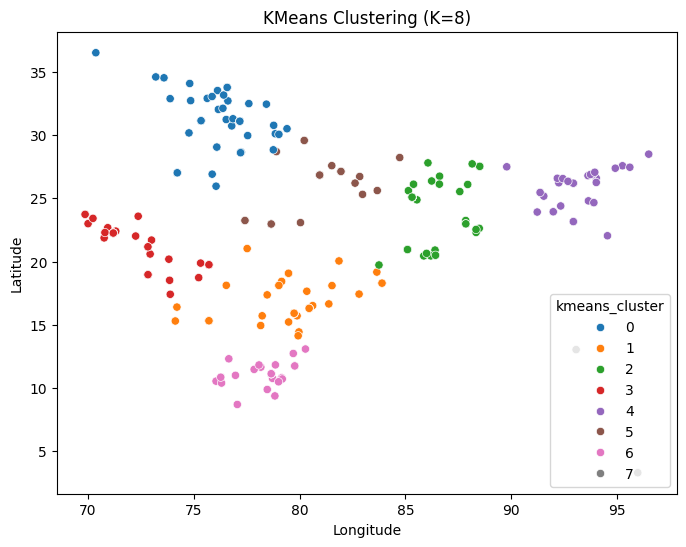

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['kmeans_cluster'],
    palette='tab10'
)
plt.title("KMeans Clustering (K=8)")
plt.show()

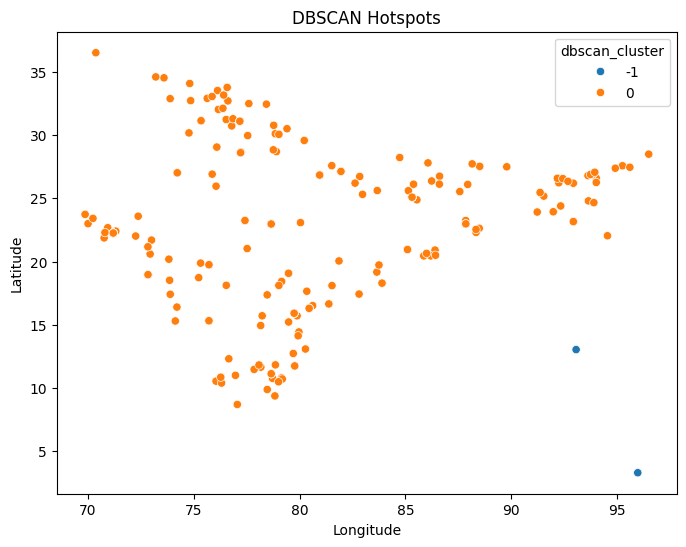

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['dbscan_cluster'],
    palette='tab10'
)
plt.title("DBSCAN Hotspots")
plt.show()